<a href="https://colab.research.google.com/github/Ayushjha02/speech-to-text/blob/main/F_speechtoText.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mouting google drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Importing essential Module**

In [37]:
import pandas as pd
import glob
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
!pip install --upgrade --force-reinstall librosa

In [42]:
import librosa
import librosa.display


**Reading metadata cointaining filename and text associated with it**

In [39]:
audio_file_metadata = pd.read_csv("/content/drive/MyDrive/metadata.csv")

In [40]:
audio_file_metadata.head()

,Unnamed: 0,id,sentence,file_name,audio_path
0,0,LJ001-0001,"Printing, in the only sense with which we are ...",LJ001-0001.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...
1,1,LJ001-0002,in being comparatively modern.,LJ001-0002.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...
2,2,LJ001-0003,For although the Chinese took impressions from...,LJ001-0003.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...
3,3,LJ001-0004,"produced the block books, which were the immed...",LJ001-0004.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...
4,4,LJ001-0005,the invention of movable metal letters in the ...,LJ001-0005.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...


In [ ]:
df = audio_file_metadata[['file_name','sentence']]
df = df.rename(columns={
    "file_name": "audio",
    "sentence": "text"
})



In [ ]:
df.head()

,audio,text
0,LJ001-0001.wav,"Printing, in the only sense with which we are ..."
1,LJ001-0002.wav,in being comparatively modern.
2,LJ001-0003.wav,For although the Chinese took impressions from...
3,LJ001-0004.wav,"produced the block books, which were the immed..."
4,LJ001-0005.wav,the invention of movable metal letters in the ...


**List out all the audio**

In [30]:
glob_list = glob.glob("/content/drive/MyDrive/wavs (1)/*.wav")


In [56]:
#play audio
ipd.Audio(glob_list[0])

In [57]:
y ,sr= librosa.load(glob_list[0])
y,sr

(array([-5.8886071e-05, -9.9764118e-05, -5.1716685e-05, ...,
         7.9115020e-04, -4.8122190e-05,  0.0000000e+00],
       shape=(76703,), dtype=float32),
 22050)

**Displaying audio file**

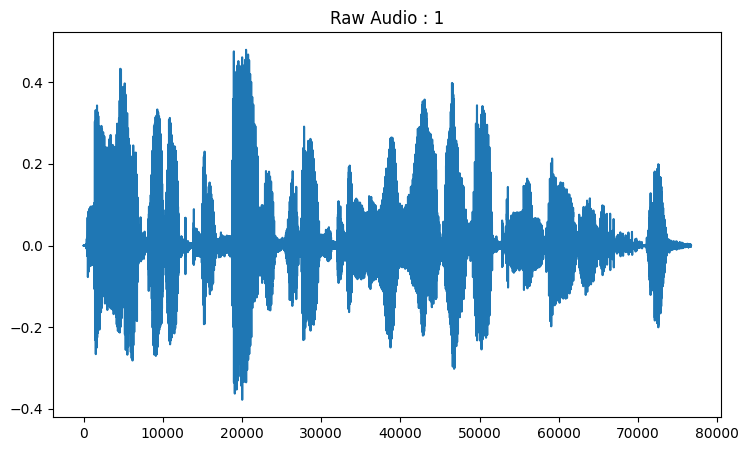

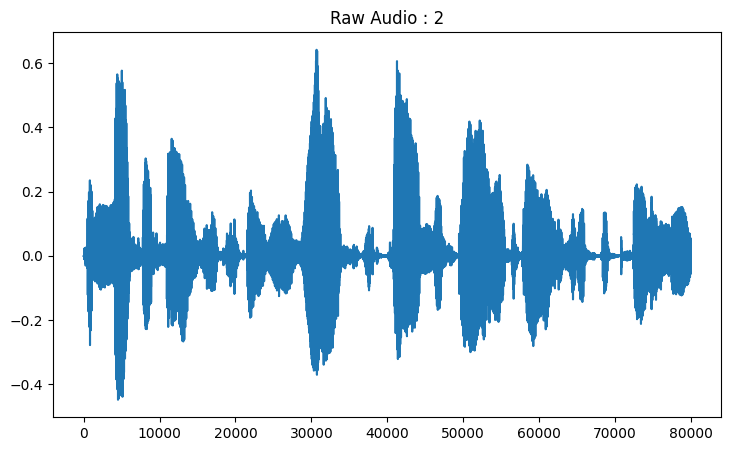

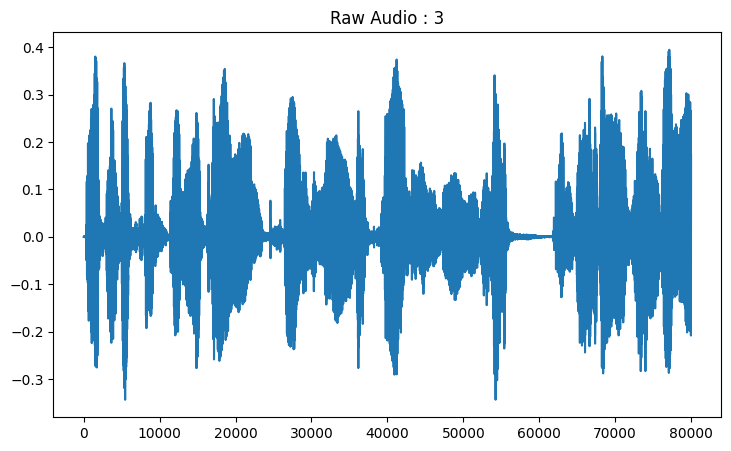

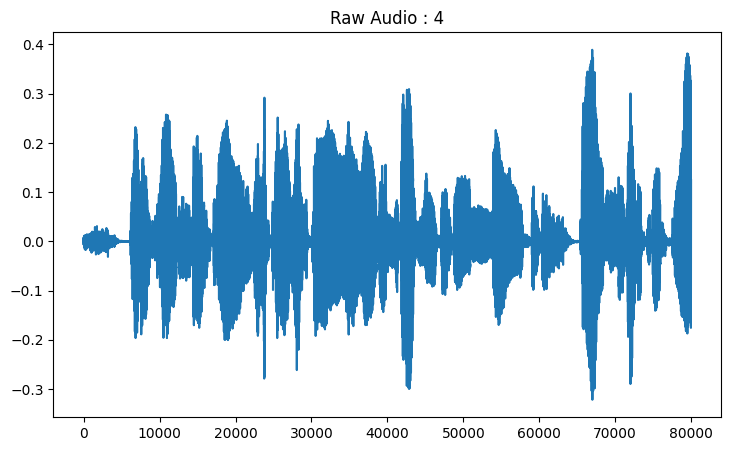

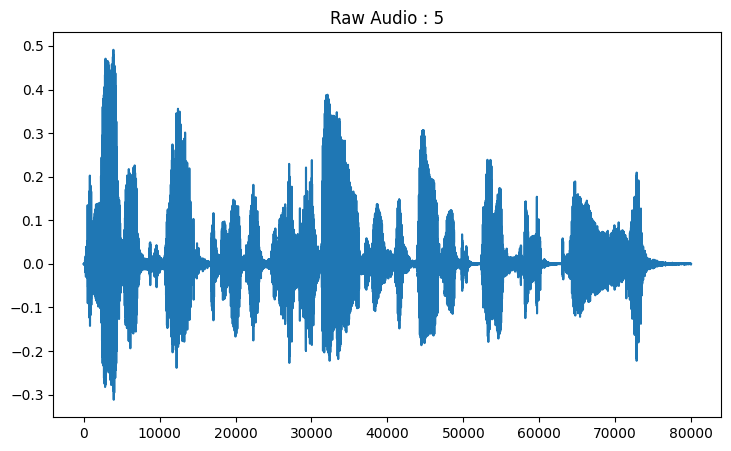

In [74]:
for i in range(5):

  y,sr = librosa.load(glob_list[i])
  plt.subplot(1,5,i+1)
  pd.Series(y[0:80000]).plot(figsize=(50,5),
                  title=f"Raw Audio : {i+1}" )
  plt.show()

AttributeError: QuadMesh.set() got an unexpected keyword argument 'title'

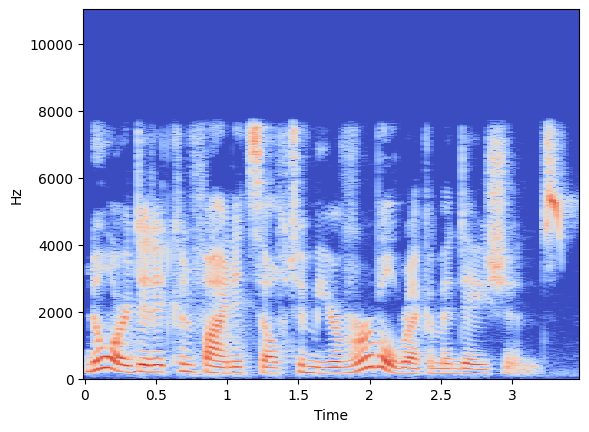

In [83]:
for i in range(5):
  y,sr = librosa.load(glob_list[i])
  s = librosa.stft(y)
  s_db = librosa.amplitude_to_db(abs(s))

  img = librosa.display.specshow(s_db,
                                sr=sr,
                                x_axis='time',
                                y_axis='hz')



In [ ]:
import os
for value in df['audio']:
 audio_path = '/content/drive/MyDrive/wavs (1)/' + value
 if os.path.exists(audio_path):
  continue
 else:
  df.drop(df[df['audio'] == value].index, inplace = True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2160 entries, 0 to 2159
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   audio   2160 non-null   object
 1   text    2160 non-null   object
dtypes: object(2)
memory usage: 50.6+ KB


**Read file from the folder**

In [ ]:
import torch
from torch.utils.data import Dataset
import librosa
import os


In [ ]:
import string

class CharTokenizer:
    def __init__(self):
        # vocabulary
        self.chars = list(string.ascii_lowercase + " '")
        self.chars.append("_")  # blank token for CTC

        self.char_to_idx = {c: i for i, c in enumerate(self.chars)}
        self.idx_to_char = {i: c for c, i in self.char_to_idx.items()}

        self.blank_idx = self.char_to_idx["_"]

    # text → tokens
    def encode(self, text):
        text = text.lower()
        return [self.char_to_idx[c] for c in text if c in self.char_to_idx]

    # tokens → text
    def decode(self, indices):
        return "".join([self.idx_to_char[i] for i in indices])

    # CTC decoding (remove duplicates + blanks)
    def ctc_decode(self, indices):
        decoded = []
        prev = None

        for i in indices:
            if i != prev and i != self.blank_idx:
                decoded.append(self.idx_to_char[i])
            prev = i

        return "".join(decoded)





In [ ]:

import torch
from torch.utils.data import Dataset
import librosa
import numpy as np
import os
import re
from pathlib import Path



def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z' ]", "", text)
    return text
class STTDataset(Dataset,CharTokenizer):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        super().__init__()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio_path = '/content/drive/MyDrive/wavs (1)/' + row["audio"]
        text = clean_text(row["text"])


        file_path = Path(audio_path)

        if file_path.exists():
            if file_path != None:
             audio, sr = librosa.load(file_path, sr=16000)

        # Convert to spectrogram
             mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=80)
             mel = torch.tensor(mel.T, dtype=torch.float32)


        # Encode text
            tokens = torch.tensor(self.encode(text=text), dtype=torch.long)

            return mel, tokens

In [ ]:
dataset = STTDataset(df)

**ANALYSING AUDIO FILES**

In [ ]:
X,Y = dataset[0]

AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'

In [ ]:
def collate_fn(batch):
    # Filter out None values from the batch
    batch = [sample for sample in batch if sample is not None]

    # If the whole batch is empty, return None
    if len(batch) == 0:
        return None

    # Separate inputs (mel spectrograms) and targets (tokens)
    mels, tokens = zip(*batch)

    # Pad mel spectrograms to the longest in the batch
    max_mel_len = max(mel.shape[0] for mel in mels)
    padded_mels = [
        torch.nn.functional.pad(mel, (0, 0, 0, max_mel_len - mel.shape[0]), 'constant', 0)
        for mel in mels
    ]
    padded_mels = torch.stack(padded_mels)

    # Pad tokens to the longest in the batch
    max_token_len = max(token.shape[0] for token in tokens)
    padded_tokens = [
        torch.nn.functional.pad(token, (0, max_token_len - token.shape[0]), 'constant', 0)
        for token in tokens
    ]
    padded_tokens = torch.stack(padded_tokens)

    # Create mel_lens and token_lens tensors for sequence lengths
    mel_lens = torch.tensor([mel.shape[0] for mel in mels], dtype=torch.long)
    token_lens = torch.tensor([token.shape[0] for token in tokens], dtype=torch.long)

    return padded_mels, padded_tokens, mel_lens, token_lens

In [ ]:
from torch.utils.data import DataLoader
if dataset is not None:
 loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

**decoding audio and text using nural network**